In [1]:
!pip install anndata=='0.8.0'

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
from sklearn.decomposition import TruncatedSVD
import pandas as pd
import os
import anndata as ad
import seaborn as sns
from scipy import sparse

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pwd()

'/scratch/data/CJ_RI'

In [18]:
dat_list = ['STARSolo/processedrun_10_2_CJ_full.h5ad',
            'STARSolo/processedrun_10_3_CJ_full.h5ad',
            'STARSolo/processedrun_10_4_CJ_full.h5ad',
            'STARSolo/processedrun_10_6_CJ_full.h5ad',
            'STARSolo/processedrun_10_7_CJ_full.h5ad',
            'STARSolo/processedrun_10_8_CJ_full.h5ad',
            'STARSolo/processedrun_11_5_CJ_full.h5ad',
            'STARSolo/processedrun_11_6_CJ_full.h5ad',
            'STARSolo/processedrun_11_7_CJ_full.h5ad',
           ]
tot_dat = sc.read_h5ad('STARSolo/processedrun_11_8_CJ_full.h5ad')
tot_dat.X = sparse.csr_matrix(tot_dat.X)
tot_dat.obs['key'] = 'Run 11 sample 8'
for item in dat_list:
    dat = sc.read_h5ad(item)
    dat.X = sparse.csr_matrix(dat.X)
    print(len(tot_dat.var_names))
    dat.obs['key'] = 'Run ' + item.split('_')[1] + ' sample ' + item.split('_')[2]
    print(item.split('_')[1] + '_' + item.split('_')[2])
    tot_dat = ad.concat([tot_dat,dat], join = 'outer')

16736
10_2


/scratch/miniconda/lib/python3.7/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


19230
10_3
19608
10_4
19809
10_6
19868
10_7
19923
10_8
19969
11_5
19974
11_6
19988
11_7


In [19]:
tot_dat

AnnData object with n_obs × n_vars = 78639 × 20032
    obs: 'n_genes', 'n_counts', 'key'

In [20]:
obs_unique = []
for item in tot_dat:
    obs_unique.append(item.obs_names.values[0] + ' ' +item.obs['key'].values[0])

In [21]:
tot_dat.obs_names = obs_unique

In [22]:
tot_dat.var_names

Index(['5S_rRNA-1', '5S_rRNA-10', '5S_rRNA-18', '5S_rRNA-20', '5S_rRNA-21',
       '5S_rRNA-23', '5S_rRNA-5', '5S_rRNA-8', '5S_rRNA-9', '7SK',
       ...
       'ZSWIM8', 'ZUP1', 'ZW10', 'ZWILCH', 'ZYG11A', 'ZYX', 'ZZEF1', 'ZZZ3',
       'prl', 'quPKCI'],
      dtype='object', length=20032)

In [23]:
tot_dat.obs_names_make_unique()
dat.obs_names_make_unique()

In [24]:
tot_dat.write(filename = 'tot_dat_CJ_joined.h5ad')

In [6]:
sc.pl.umap(tot_dat, color = 'n_genes') 

KeyError: "Could not find entry in `obsm` for 'umap'.\nAvailable keys are: []."

In [6]:
dat = sc.read_h5ad('tot_dat_STARSolo_full.h5ad')

In [8]:
dat.obs['type'] = 'cg'

In [15]:
dat

AnnData object with n_obs × n_vars = 78639 × 16295
    obs: 'n_genes', 'n_counts', 'key', 'type'

In [16]:
tot_dat

AnnData object with n_obs × n_vars = 72547 × 27869
    obs: 'n_genes', 'n_counts', 'key', 'type'

In [9]:
tot_dat.obs['type'] = 'ct'

In [19]:
counts = pd.concat([dat.obs, tot_dat.obs], axis = 0)

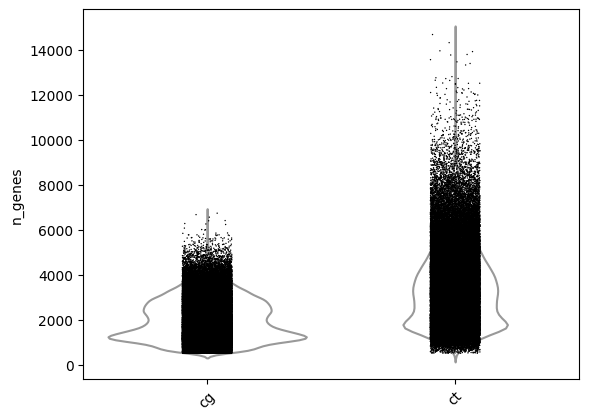

In [21]:
from matplotlib import rcParams

rcParams['figure.figsize'] = 11.7,8.27
sns.reset_orig()
sns.violinplot(x = 'type', y = 'n_genes', data = counts, color = 'white')
sns.stripplot(x = 'type', y = 'n_genes', data = counts, color = 'black', size = 1)
plt.xticks(rotation=45)
plt.xlabel(None)
plt.show()

In [42]:
fin = []
for i in range(len(dat.obs_names)):
    if dat.obs_names[i] in tot_dat.obs_names:
        j = list(tot_dat.obs_names).index(dat.obs_names[i])
        fin.append(dat.obs.loc[dat.obs_names[i],'n_genes'] - tot_dat.obs.loc[tot_dat.obs_names[j],'n_genes'])
    if i % 100 == 0:
        print(i)
    if i == 10000:
        break

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000


In [37]:
len(fin)

1001

(array([1.000e+00, 7.000e+00, 4.100e+01, 1.610e+02, 8.810e+02, 3.441e+03,
        2.652e+03, 2.000e+01, 7.000e+00, 1.000e+00]),
 array([-46124., -39761., -33398., -27035., -20672., -14309.,  -7946.,
         -1583.,   4780.,  11143.,  17506.], dtype=float32),
 <BarContainer object of 10 artists>)

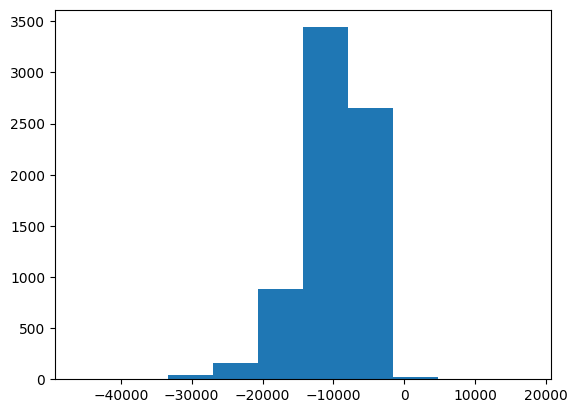

In [41]:
plt.hist(fin)

In [4]:
dat

AnnData object with n_obs × n_vars = 982 × 26037
    obs: 'n_genes', 'n_counts', 'leiden_clusters'
    var: 'n_cells', 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'leiden_clusters_colors', 'preprocess_args', 'ranked_genes', 'run_args'
    obsm: 'X_pca', 'X_processed', 'X_umap'
    varm: 'PCs'
    layers: 'X_disp'
    obsp: 'connectivities', 'distances', 'nnm'

In [6]:
dat.X

<982x26037 sparse matrix of type '<class 'numpy.float32'>'
	with 388838 stored elements in Compressed Sparse Row format>

In [9]:
for item in dat.X:
    print(item)
    break

  (0, 274)	1.4416349
  (0, 1043)	1.4416349
  (0, 1217)	1.4416349
  (0, 1452)	1.4416349
  (0, 2232)	1.8377123
  (0, 2493)	1.4416349
  (0, 2608)	1.4416349
  (0, 2670)	1.8377123
  (0, 2706)	1.4416349
  (0, 2989)	1.4416349
  (0, 3013)	1.4416349
  (0, 3045)	1.4416349
  (0, 3106)	1.4416349
  (0, 3111)	2.1481433
  (0, 3132)	1.8377123
  (0, 3261)	1.4416349
  (0, 3321)	1.4416349
  (0, 3327)	1.4416349
  (0, 3363)	2.620318
  (0, 3443)	2.1481433
  (0, 3447)	1.4416349
  (0, 3477)	1.4416349
  (0, 3689)	1.8377123
  (0, 3729)	2.1481433
  (0, 3800)	1.8377123
  :	:
  (0, 22496)	2.1481433
  (0, 23435)	2.1481433
  (0, 23890)	1.4416349
  (0, 23914)	1.8377123
  (0, 23962)	1.4416349
  (0, 23984)	1.4416349
  (0, 24023)	2.1481433
  (0, 24091)	1.4416349
  (0, 24223)	1.4416349
  (0, 24302)	1.4416349
  (0, 24354)	1.4416349
  (0, 24503)	1.4416349
  (0, 24515)	1.4416349
  (0, 24742)	1.4416349
  (0, 24912)	1.4416349
  (0, 25171)	1.4416349
  (0, 25187)	1.4416349
  (0, 25304)	2.620318
  (0, 25347)	2.1481433
  (0, 2550